In [ ]:
!pip install qiskit-ibm-runtime
!pip install 'qiskit[visualization]'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 96.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.8/64.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.5/130.5 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 7.7 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.3
    Uninstalling requests-2.32.3:
      Successfully uninstalled requests-2.32.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the so

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize

from qiskit.circuit.library import efficient_su2
from qiskit.circuit.library import RealAmplitudes
from qiskit.circuit.library import QAOAAnsatz
from qiskit.circuit.library import hamiltonian_variational_ansatz
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.circuit import QuantumCircuit, Parameter

from qiskit_ibm_runtime import QiskitRuntimeService, Session
from qiskit_ibm_runtime import EstimatorV2 as Estimator

from qiskit.quantum_info import Statevector

from math import pi


import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 100

In [ ]:
!pip install qiskit-aer
from qiskit_aer import AerSimulator
backend=AerSimulator()

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 79.3 MB/s eta 0:00:00


# **Looped 4 Qubit Ising Model (Quantum)**

In [ ]:
#graph of h vs E (initialized groups)
optimized_x = []
optimal_fun = []
num_func_evals = []
max_constraint_violation = []
success_flag =[]
message = []

ideal_gs_energy = []

In [ ]:
h_val = [-2, -1.75,-1.5,-1.25,-1,-0.75,-0.5,-0.25,0, 0.25, 0.5, 0.75, 1,1.25,1.5,1.75,2]
h_values = np.arange(-2,2.1,0.05)

In [ ]:
#create cost function
def cost_function(params, ansatz, hamiltonian, estimator):
  pub = (ansatz, [hamiltonian],[params])
  result = estimator.run(pubs=[pub]).result()
  energy=result[0].data.evs[0]

  cost_history_dict["iters"] +=1
  cost_history_dict["prev_vector"] = params
  cost_history_dict["cost_history"].append(energy)
  print(f"Iters.done: {cost_history_dict['iters']} [Current Cost: {energy}]")

  return energy

In [ ]:
for h in h_values:
  #Hamiltonian Define
  # H=ZZII+IZZI+ IIZZ+ XIII+IXII+IIXI+IIIX
  J=1
  hamil = SparsePauliOp.from_list([("ZZII",-J),("IZZI",-J),("IIZZ", -J),("XIII",h),("IXII",h),("IIXI",h),("IIIX",h)])
  hamiltonian = sum(hamil)
  #print(hamiltonian)

  #Finding eigenvalues/vectors
  print("THE EIGENSTUFF")
  eigenvalues, eigenvectors = np.linalg.eigh(hamiltonian.to_matrix())
  print("Eigenvalues:")
  for eigenvalue in eigenvalues:
      print(eigenvalue)

  print("\n Eigenstates:")
  for eigenvector in eigenvectors:
      print(Statevector(eigenvector))
  ideal_gs_energy.append(eigenvalues[0])
  #print(ideal_gs_energy)

  #Define ansatz
  ansatz = efficient_su2(hamiltonian.num_qubits)
  #ansatz.decompose().draw("mpl", style = "iqp")

  #Determine number of parameters
  num_params = ansatz.num_parameters
  print(num_params)

  #adjust ansatz to isa form (for ease of simulation)
  ansatz_isa = pm.run(ansatz)
  #ansatz_isa.draw(output="mpl", idle_wires=False, style = "iqp")

  hamiltonian_isa = hamiltonian.apply_layout(layout=ansatz_isa.layout)

  cost_history_dict = {"prev_vector":None, "iters": 0, "cost_history":[]}

  #initial parameters - randomized initially
  x0 = 2 * np.pi * np.random.random(num_params)

  #the simulation
  with Session(backend=backend) as session:
    estimator = Estimator(mode=session)
    estimator.options.default_shots=10000

    res = minimize( cost_function, x0, args = (ansatz_isa, hamiltonian_isa, estimator), method="cobyla")

  print(res)

  all(cost_history_dict["prev_vector"]==res.x)

  cost_history_dict["iters"]==res.nfev

  #h_values=[-2,-1.75,-1.5,-1.25,-1,-0.75,-0.5,-0.25,0] # This line is redundant
  optimized_x.append(res.x)
  optimal_fun.append(res.fun)
  num_func_evals.append(res.nfev)
  max_constraint_violation.append(res.maxcv)
  success_flag.append(res.success)
  message.append(res.message)


Streaming output truncated to the last 5000 lines.
Iters.done: 14 [Current Cost: -1.4250400000000027]
Iters.done: 15 [Current Cost: -1.269950000000004]
Iters.done: 16 [Current Cost: 0.02134999999999987]
Iters.done: 17 [Current Cost: -1.2566600000000019]
Iters.done: 18 [Current Cost: -1.665250000000004]
Iters.done: 19 [Current Cost: -1.2843000000000038]
Iters.done: 20 [Current Cost: -1.6162200000000035]
Iters.done: 21 [Current Cost: -1.6209200000000037]
Iters.done: 22 [Current Cost: -1.693720000000004]
Iters.done: 23 [Current Cost: -1.9007100000000041]
Iters.done: 24 [Current Cost: -1.9253400000000036]
Iters.done: 25 [Current Cost: -1.0193000000000019]
Iters.done: 26 [Current Cost: -0.6163200000000013]
Iters.done: 27 [Current Cost: -1.2472100000000037]
Iters.done: 28 [Current Cost: -3.1143800000000046]
Iters.done: 29 [Current Cost: -2.6439000000000044]
Iters.done: 30 [Current Cost: -2.5607400000000036]
Iters.done: 31 [Current Cost: -3.0117200000000044]
Iters.done: 32 [Current Cost: -2.9

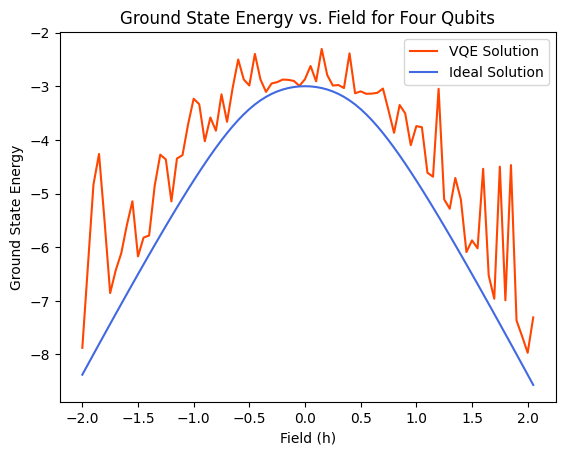

In [ ]:
 import scipy, pylab
ax = pylab.subplot(111)
ax.plot(h_values, optimal_fun, "orangered", linewidth = 1.5)
ax.plot(h_values, ideal_gs_energy, "royalblue", linewidth = 1.5)
plt.title("Ground State Energy vs. Field for Four Qubits")
plt.xlabel("Field (h)")
plt.ylabel("Ground State Energy")
plt.legend(["VQE Solution", "Ideal Solution"])
ax.figure.show()

# Goal

Duplicate the VQE simulation code from earlier, modify it to run 5 simulations for each value of `h`, store the results, and plot the averaged VQE ground state energies and the ideal ground state energies against `h_values` on the same graph.

In [ ]:
h_valu = np.arange(-2,2.5, 0.05)

In [ ]:
# Initialize a list to store the averaged optimal energies
averaged_optimal_fun = []

for h in h_valu:
    # Hamiltonian Define
    # H=ZZII+IZZI+ IIZZ+ XIII+IXII+IIXI+IIIX
    J = 1
    hamil = SparsePauliOp.from_list([("ZZII", -J), ("IZZI", -J), ("IIZZ", -J), ("XIII", h), ("IXII", h), ("IIXI", h), ("IIIX", h)])
    hamiltonian = sum(hamil)

    # Finding eigenvalues/vectors (only needed for ideal comparison, can keep outside inner loop)
    print(f"Calculating ideal ground state energy for h = {h}")
    print("THE EIGENSTUFF")
    eigenvalues, eigenvectors = np.linalg.eigh(hamiltonian.to_matrix())
    print("Eigenvalues:")
    for eigenvalue in eigenvalues:
        print(eigenvalue)

    print("\n Eigenstates:")
    for eigenvector in eigenvectors:
       print(Statevector(eigenvector))
    ideal_gs_energy.append(eigenvalues[0])

    # Define ansatz (can keep outside inner loop)
    ansatz = efficient_su2(hamiltonian.num_qubits)

    # Determine number of parameters (can keep outside inner loop)
    num_params = ansatz.num_parameters

    # adjust ansatz to isa form (for ease of simulation) (can keep outside inner loop)
    ansatz_isa = pm.run(ansatz)
    hamiltonian_isa = hamiltonian.apply_layout(layout=ansatz_isa.layout)

    # List to store optimal energies for the current h value
    optimal_energies_for_h = []

    # Run the VQE simulation 5 times for the current h value
    for i in range(5):
        print(f"Running VQE for h = {h}, run {i+1}")
        cost_history_dict = {"prev_vector": None, "iters": 0, "cost_history": []}

        # initial parameters - randomized initially for each run
        x0 = 2 * np.pi * np.random.random(num_params)

        # the simulation
        with Session(backend=backend) as session:
            estimator = Estimator(mode=session)
            estimator.options.default_shots = 10000

            res = minimize(cost_function, x0, args=(ansatz_isa, hamiltonian_isa, estimator), method="cobyla")

        print(f"Run {i+1} finished for h = {h}. Optimal energy: {res.fun}")
        optimal_energies_for_h.append(res.fun)

    # Calculate the average optimal energy for the current h value
    avg_energy = np.mean(optimal_energies_for_h)
    averaged_optimal_fun.append(avg_energy)
    print(f"Averaged optimal energy for h = {h}: {avg_energy}")

    # Store other results from the last run (optional, for debugging or further analysis if needed)
    # optimized_x.append(res.x)
    # num_func_evals.append(res.nfev)
    # max_constraint_violation.append(res.maxcv)
    # success_flag.append(res.success)
    # message.append(res.message)


Streaming output truncated to the last 5000 lines.
Iters.done: 281 [Current Cost: -9.338530000000016]
Iters.done: 282 [Current Cost: -9.364720000000016]
Iters.done: 283 [Current Cost: -9.391020000000015]
Iters.done: 284 [Current Cost: -9.345240000000016]
Iters.done: 285 [Current Cost: -9.365230000000016]
Iters.done: 286 [Current Cost: -9.362500000000015]
Iters.done: 287 [Current Cost: -9.311440000000015]
Iters.done: 288 [Current Cost: -9.316940000000015]
Iters.done: 289 [Current Cost: -9.366470000000016]
Iters.done: 290 [Current Cost: -9.393570000000016]
Iters.done: 291 [Current Cost: -9.379440000000017]
Iters.done: 292 [Current Cost: -9.359380000000016]
Iters.done: 293 [Current Cost: -9.381590000000017]
Iters.done: 294 [Current Cost: -9.336730000000015]
Iters.done: 295 [Current Cost: -9.351790000000015]
Iters.done: 296 [Current Cost: -9.351610000000015]
Iters.done: 297 [Current Cost: -9.340400000000017]
Iters.done: 298 [Current Cost: -9.309880000000016]
Iters.done: 299 [Current Cost: 

## Average Results

### Subtask:
Calculate the average of the 5 optimal energies for each `h` value and store them in a new list.

**Reasoning**:
To compare the VQE results with the ideal solution, we need to average the optimal energies obtained from the 5 runs for each `h` value. This will provide a single VQE energy value for each `h` to plot.

In [ ]:
# The averaging is already done in the previous cell
# The averaged optimal energies are stored in the `averaged_optimal_fun` list.

# You can print the averaged results to verify:
# print("Averaged Optimal Energies:", averaged_optimal_fun)

## Plot Results

**Reasoning**:
Plotting the averaged VQE results and the ideal ground state energies on the same graph will allow for a visual comparison of how well the VQE simulation performed compared to the theoretical ideal solution across different values of `h`.

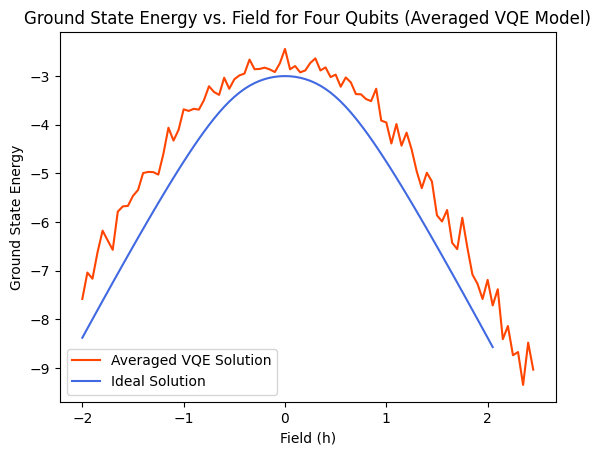

In [ ]:
import matplotlib.pyplot as plt

# Ensure h_valu and averaged_optimal_fun have the same length
# If not, you might need to re-run the simulation or check the data
#if len(h_valu) != len(averaged_optimal_fun):
   # print("Warning: Length of h_valu and averaged_optimal_fun do not match.")
   # print(f"Length of h_valu: {len(h_valu)}")
   # print(f"Length of averaged_optimal_fun: {len(averaged_optimal_fun)}")
    # You might need to adjust the lists or re-run the simulation
    # For now, we'll proceed with the minimum length to avoid errors, but this might not be accurate
  #  min_len = min(len(h_valu), len(averaged_optimal_fun))
  #  h_valu_plot = h_valu[:min_len]
  ###  averaged_optimal_fun_plot = averaged_optimal_fun[:min_len]
#else:
   # h_valu_plot = h_valu
   # averaged_optimal_fun_plot = averaged_optimal_fun

# Ensure h_valu and ideal_gs_energy have the same length
#if len(h_valu) != len(ideal_gs_energy):
  ##  print("Warning: Length of h_valu and ideal_gs_energy do not match.")
   # print(f"Length of h_valu: {len(h_valu)}")
   # print(f"Length of ideal_gs_energy: {len(ideal_gs_energy)}")
    # You might need to adjust the lists or re-run the simulation
    # For now, we'll proceed with the minimum length to avoid errors, but this might not be accurate
  #  min_len = min(len(h_valu), len(ideal_gs_energy))
   # h_valu_plot = h_valu[:min_len]
    #ideal_gs_energy_plot = ideal_gs_energy[:min_len]
#else:
   #  ideal_gs_energy_plot = ideal_gs_energy


ax = plt.subplot(111)
ax.plot(h_valu, averaged_optimal_fun, "orangered", linewidth = 1.5, label="Averaged VQE Solution")
ax.plot(h_values, ideal_gs_energy[:82], "royalblue", linewidth = 1.5, label="Ideal Solution")
plt.title("Ground State Energy vs. Field for Four Qubits (Averaged VQE Model)")
plt.xlabel("Field (h)")
plt.ylabel("Ground State Energy")
plt.legend()
ax.figure.show()

# Error Calculations

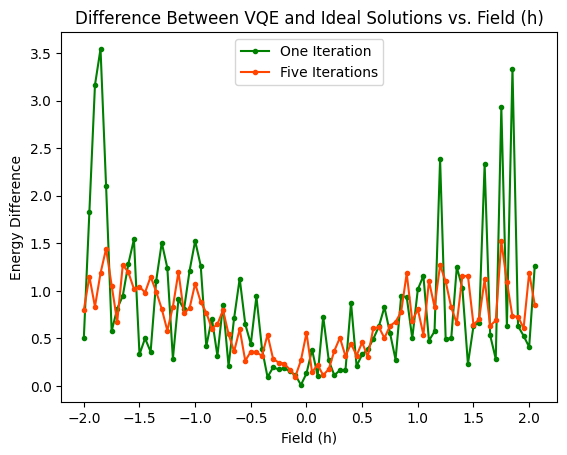

In [ ]:
# Calculate the difference between VQE solution and ideal solution
energy_difference_1 = [vqe_1 - ideal_1 for vqe_1, ideal_1 in zip(optimal_fun, ideal_gs_energy)]
energy_difference_2 = [vqe_2 - ideal_1 for vqe_2, ideal_1 in zip(averaged_optimal_fun, ideal_gs_energy)]

energy_difference_2_plot = energy_difference_2[:len(h_values)]

# Plot the difference
ax = pylab.subplot(111)
ax.plot(h_values, energy_difference_1, "green", marker = '.', linewidth = 1.5, label = "One Iteration")
ax.plot(h_values, energy_difference_2_plot, "orangered", marker = '.', linewidth = 1.5, label = "Five Iterations")
plt.title("Difference Between VQE and Ideal Solutions vs. Field (h)")
plt.legend()
plt.xlabel("Field (h)")
plt.ylabel("Energy Difference")
ax.figure.show()